## LangChain

LangChain is a framework designed to simplify the development of applications powered by large language models (LLMs).

* It provides tools for connecting LLMs to external data sources, like databases or APIs, and for creating chains of actions.
* This allows developers to build sophisticated applications that go beyond simple text generation.
* LangChain facilitates tasks like document summarization, question answering, and creating agents that can interact with the real world.
* By offering modular components and abstractions, it accelerates LLM app development, making complex workflows more manageable.

For more information, please refer to https://www.langchain.com/

## Retrieval Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is a technique that enhances the capabilities of large language models (LLMs) by grounding them in external knowledge sources. Instead of relying solely on their pre-trained data, RAG allows LLMs to retrieve relevant information from a database or knowledge base in real-time.

Here's how it works: when a user poses a question, the system first retrieves relevant documents or passages from the external source. This retrieved information is then combined with the user's query and fed into the LLM, which generates a response based on both the retrieved knowledge and its pre-existing understanding.

RAG improves accuracy, reduces hallucinations, and enables LLMs to answer questions about information they weren't originally trained on.

 This is particularly useful for applications requiring up-to-date or domain-specific knowledge. RAG effectively bridges the gap between static LLMs and dynamic, real-world data.

## RAG Using LangChain

We will build a Retreival Augmented Generation Application using the following steps that we have discussed in the lesson.
* Step 1: Document Loading
* Step 2: Splitting Text into Chunks
* Step 3: Storage Text as Vectorstore
* Step 4: Query and Retreival text
* Step 5: Output answer with retreival text and LLM Augmented Generation

Dataset: encyclopedia of medicine PDF file

![RAG Workflow](https://miro.medium.com/v2/resize:fit:1200/format:webp/1*-TPXZmeTpI9hezbZqA4NpA.png)

##Load Libraries

In [8]:
!pip install -U langchain langchain_community langchain_classic langchain_groq langchain_chroma langchain_huggingface langchain_text_splitters chromadb python-dotenv gdown pypdf sentence-transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Download the .env into the colab virtual drive


In [1]:
import gdown
url = 'https://drive.google.com/file/d/1f-X_cbCcJG0JrJl2FsCNceuA6POKjnXm/view?usp=drive_link'
output_path = '.env'
gdown.download(url, output_path, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1f-X_cbCcJG0JrJl2FsCNceuA6POKjnXm
To: /content/.env
100%|██████████| 71.0/71.0 [00:00<00:00, 226kB/s]


'.env'

In [2]:
from dotenv import load_dotenv
import os

# load .env file to environment
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

---
> NOTE: Please DO NOT use the Groq API Key outside of this workshop. Get a free key at https://console.groq.com/keys and store it in your `.env` file as `GROQ_API_KEY=...`
---

In [3]:
from langchain_groq import ChatGroq
import os

llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0.9)


#Test the LLM
print(llm.invoke([{'role':'user', 'content':'Which is the largest country by area in the world?'}]).content)

The largest country by area in the world is Russia, covering approximately 17.1 million square kilometers (6.6 million square miles). It spans across much of northern Eurasia and accounts for about 11% of the Earth's land area.


##Step 1: Document Loading

Create a directory name data. Copy the pdf document into the directory created. Filename: encyclopedia-of-medicine.pdf

In [4]:
!mkdir data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Read the pdf doucment into multiple pages of text.

In [5]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader

# Extract Data From the PDF File
def load_pdf_file(data):
    loader = DirectoryLoader(data, glob="*.pdf", loader_cls=PyPDFLoader)
    documents = loader.load()
    return documents

extracted_data = load_pdf_file(data='./data/')

/tmp/ipykernel_2711/1923104849.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader


In [6]:
print(type(extracted_data), len(extracted_data))   # Organize by the pages. Total pages: 68.

<class 'list'> 20


In [ ]:
extracted_data[2]

In [ ]:
extracted_data[-1]

##Step 2: Splitting Text into Chunks

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Split the Data into Text Chunks
def text_split(extracted_data):
    text_splitter=RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=20)  # size by characters
    text_chunks=text_splitter.split_documents(extracted_data)
    return text_chunks

text_chunks=text_split(extracted_data)
print("Length of Text Chunks", len(text_chunks))

Length of Text Chunks 35


In [ ]:
text_chunks[0]

In [ ]:
text_chunks[1]

In [ ]:
text_chunks[559]

In [ ]:
text_chunks[-1]

##Step 3: Storage Text as Vectorstore

Vector databases are specialized databases designed to efficiently store, manage, and query high-dimensional vector data.

These vectors represent data points in a multi-dimensional space, capturing the semantic meaning or features of items like text, images, or audio. Unlike traditional databases that rely on structured data and exact matches, vector databases excel at similarity searches.

![Vector Space](https://images.contentstack.io/v3/assets/blt7151619cb9560896/blt5c3b8fcafa132cf2/667daaeb82ce1d23f7312f32/lorbgyz9ffm8ui8jh-vector-database-search1.png)

> **Note:** Groq does not currently offer an embeddings API, so this notebook uses a free, local Hugging Face sentence-transformer model (`sentence-transformers/all-MiniLM-L6-v2`) for embeddings, while Groq is used for the fast LLM generation and reranking steps.

In [8]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectordb = Chroma.from_texts([t.page_content for t in text_chunks],
                             embeddings,
                             collection_name="meddoc",
                             persist_directory="./meddoc_db")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##Step 4: Query and Retreival text

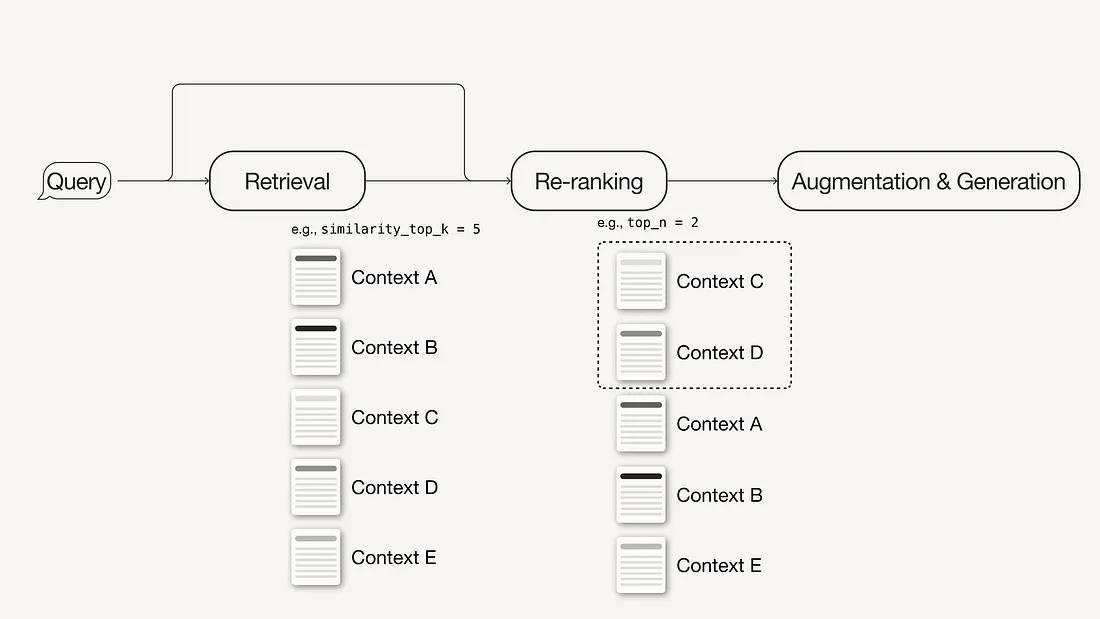

1. What "retrieval top-K" does

When you do retrieval (e.g. vectorstore.similarity_search(query, k=10)),
the retriever selects the top-K documents based on vector similarity between
the query embedding and document embeddings.

The retriever uses a simple numeric metric (usually cosine similarity or dot-product).
It is fast but shallow — it only measures how "close" the embeddings are in semantic space.
It does not understand context, contradiction, or logical entailment.

Example:
Query: "What's the latest annual leave policy for VirtuWorks employees?"
Retriever (top-10) might return:
- Doc A: "Annual leave is 14 days."
- Doc B: "Annual leave is 18 days after 3 years."
- Doc C: "Version 2 HR Policy updated leave to 18 days."
- Doc D: "Version 1 policy states 15 days."

All four look semantically similar ("annual leave"), so they all rank high —
even old or contradictory ones.


2. What "reranking" does

After retrieving those top-K documents, the reranker (often a cross-encoder model
like bge-reranker, ms-marco-MiniLM, or an LLM-based scorer) re-evaluates each
candidate together with the query text.

It calculates a true relevance score by reading both the query and each document —
essentially performing a mini question-answer matching step.

So instead of only vector distance, it uses:
- full token interaction (query + doc as joint input)
- semantic coherence
- factual alignment
- logical consistency
- recency cues (if text mentions version/date)

In the same example:
The reranker can learn that "Version 2 HR Policy" and "18 days" are more relevant
to "latest" than "14 days" or "15 days".


3. Why "retrieval top-K" ≠ "relevance"

Because:

Factor                         | Retriever (vector search)   | Reranker
-------------------------------|-----------------------------|--------------------------
Mechanism                      | Embedding distance          | Textual inference
Context awareness              | Low (token-agnostic)        | High (cross-attention on query+doc)
Precision                      | Broad recall                | Fine-grained relevance
Speed                          | Very fast                   | Slower
Handles contradictions         | No                          | Yes
Understands modifiers (e.g. "latest", "after 3 years") | No | Yes

Thus, retrieval top-K just gives candidates — not necessarily the most relevant or correct ones.
Reranking actually determines which are the best among them.


4. How they work together

A well-tuned RAG uses both:

Retriever → Get top-K possibly relevant docs (e.g. K=20 or 30).

Reranker → Re-score and keep top-N most relevant (e.g. N=5).

So the reranker acts as a precision filter on top of the retriever’s broad recall.


In [9]:
question = "How many days of annual leave do VirtuWorks employees get?"
results = vectordb.similarity_search(question, k=3)
print(len(results))
print(results[0])

3
page_content='12. Termination, Resignation & Exit Management

Notice periods per contract or MOM guidelines (1–4 weeks).

Final salary, unused leave, and CPF contributions settled upon exit.

Exit interviews conducted for feedback and knowledge transfer.

Return of company property and deactivation of accounts required.

Rehire eligibility is assessed on case-by-case basis.'


In [ ]:
question = "How many days of annual leave do VirtuWorks employees get?"
results = vectordb.similarity_search(question, k=5)
print(len(results))
print(results[-1])

In [10]:
# Specifying top k
retriever = vectordb.as_retriever(search_kwargs={ "k" : 10})
print(retriever.invoke("How many days of annual leave do VirtuWorks employees get?")[0])

page_content='12. Termination, Resignation & Exit Management

Notice periods per contract or MOM guidelines (1–4 weeks).

Final salary, unused leave, and CPF contributions settled upon exit.

Exit interviews conducted for feedback and knowledge transfer.

Return of company property and deactivation of accounts required.

Rehire eligibility is assessed on case-by-case basis.'


In [11]:

# Import Runnables
from langchain_core.runnables import RunnablePassthrough

# Import Output Parser
from langchain_core.output_parsers import StrOutputParser


from langchain_core.runnables import RunnablePassthrough
# === Utility function to format retrieved documents ===
def format_docs(docs):
    """Combine multiple document texts into a single string for the prompt."""
    return "\n\n".join(doc.page_content for doc in docs)
# === End of format_docs ===


In [12]:
# === Prompt Template for the RAG System ===
from langchain_core.prompts import PromptTemplate

prompt_template = """You are an AI assistant helping answer questions based on the given context.
Use only the information provided in the context to answer the question.

Context:
{context}

Question:
{question}

Answer:"""

prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=prompt_template
)

# Reranking Compressor in RAG

In a Retrieval-Augmented Generation (RAG) pipeline, a **reranking compressor** helps improve the quality of retrieved documents before feeding them into an LLM for answer generation.

---

## How it Works

1. **Base Retriever**
   - Fetches candidate documents from a vector store based on the user query.
   - Example: top-10 documents based on similarity scores.

2. **LLM-based Compression & Reranking**
   - The `LLMChainExtractor` reads all retrieved documents **in the context of the query**.
   - It extracts only the most **relevant content**.
   - This step serves two purposes:
     1. **Compression**: removes unnecessary sentences or paragraphs.
     2. **Implicit Reranking**: selects the portions most useful for answering the query, prioritizing them over less relevant content.

3. **Output**
   - The LLM returns a **compressed and prioritized set of passages**.
   - These are then used by the RAG chain to generate the final answer.

---

## Key Points

- **No explicit numeric reranking** (like cosine similarity or BM25 scores) is performed.  
- The reranking is **query-aware** and **semantic**, performed by the LLM itself.  
- Different queries can produce different “top passages” from the same set of documents.  
- Reduces noise and token usage while improving the accuracy of the generated answer.

---

> **Update note:** As of LangChain 1.x, `ContextualCompressionRetriever` and the `document_compressors` (including `LLMChainExtractor`) were removed from the core `langchain` package and now live in the separate **`langchain_classic`** package (`pip install langchain_classic`). The import paths below have been updated accordingly, and the reranker is driven by the Groq LLM instead of OpenAI.

In [13]:
# === 🆕 Add Reranking to the RAG Pipeline ===
# The reranker uses LangChain's ContextualCompressionRetriever with LLMChainExtractor
# It will rerank and compress the retrieved context before passing to the LLM
# NOTE: these moved from `langchain.retrievers` to `langchain_classic.retrievers` in LangChain 1.x

from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor

# Create reranking compressor using the same LLM (now Groq) as the RAG
compressor = LLMChainExtractor.from_llm(llm)

# Wrap the existing retriever with the reranker
rerank_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=retriever
)

# Replace 'retriever' with 'rerank_retriever' in the RAG chain setup
rag_chain = (
    {"context": rerank_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# === End of Reranking Integration ===


##Step 5: Output answer with retreival text and LLM Augmented Generation

Augmentation

Generation

Finally, we are going to create a RAG Chain. For that, we are going to use LCEL (LangChain Expression Language) Runnable function.



In [14]:
# Replace 'retriever' with 'rerank_retriever' in the RAG chain setup
rag_chain = (
    {"context": rerank_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# === End of Reranking Integration ===


In [15]:
rag_chain.invoke( "How many days of annual leave do VirtuWorks employees get?")


'According to the provided context, the annual leave entitlement increases with service length, with a minimum of 7 days after the first year. However, for staff with more than 3 years of service, the total annual leave is 18 days (14 base + 4 extra). \n\nSo, the answer depends on the length of service: \n- Minimum 7 days after the first year\n- 14 days for those with less than 3 years of service\n- 18 days for those with more than 3 years of service.'

In [16]:
print(rag_chain.invoke( "Which HR policy version is final?"))


v2.3 is the final HR policy version, unless Legal makes changes to clause 7.


In [17]:
print(rag_chain.invoke("How should an employee request emergency leave?"))

To request emergency leave, an employee should use the HR portal, select "Emergency", and an auto email will be sent to their manager.


## 🧪 Test Questions for Evaluating Reranking

These questions are designed to challenge the reranker — they include ambiguity, contradictions, and multi-document dependencies.

| **Category** | **Example Question** | **Expected Challenge** |
|---------------|----------------------|-------------------------|
| **Policy confusion** | “How many days of annual leave do VirtuWorks employees get?” | Tests if reranker can find *latest version (18 days for >3 years)* among contradictory mentions (14, 15, 18). |
| **Document versioning** | “Which HR policy version is final?” | Must locate “v2.3 is final” note in email. |
| **Automation projects** | “What RAG project is the HR department testing?” | Checks ability to extract “AI HR assistant” / “resume parser pilot” from scattered text. |
| **Address updates** | “What is the current VirtuWorks office location?” | Reranker should pick “Tower 2, 12th floor” from multiple mentions. |
| **Policy topic** | “Where can employees report harassment issues?” | Only mentioned in HR policy summary and chat fragments. |
| **Reranking validation** | “What improvement was observed after adding the reranker?” | Only appears in the engineering note (“context irrelevant 40% → improved precision”). |
| **Leave application procedure** | “How should an employee request emergency leave?” | Found in FAQ fragment, not structured clearly. |
| **Data inconsistency** | “Which document names are causing confusion for HR?” | Must detect chaotic file names like `Policy_final_FINAL_use_this.pdf`. |
| **Meeting follow-ups** | “What unresolved issues were noted in the August meeting?” | Reranker must prioritize “unresolved” summary lines at the end. |
